Maciek Gilecki 173142 Lab 4

In [1]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
mode = "rgb_array"
if mode == "None":
    mode = None


(16, 4, 0)


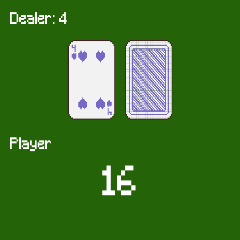

In [2]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [3]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [4]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [5]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((26, 4, 0), -1.0, True, False)

In [6]:
env.close()

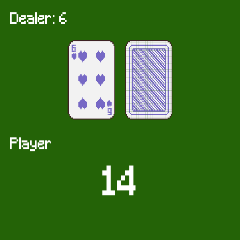

nagroda = 1.0, liczba punktów graczy = 14


In [7]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [8]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

1, obserwation, (23, 10, 0), -1.0, True
nagroda = -1.0, liczba punktów gracza = 23, liczba punktów przeciwnika = 10


Taxi

254


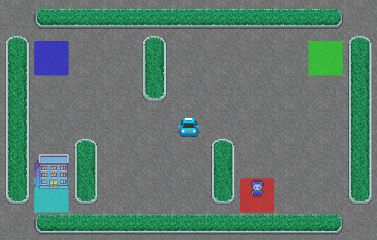

In [9]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [10]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [11]:
def flatten_state(env, obs):
    if isinstance(obs, int): # dla taxi
        return obs
    else: # dla blackjack
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
        return ans

def max_states(env, obs):
    prod = 1
    if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
        for i in range(len(env.observation_space)):
            prod *= env.observation_space[i].n
    else:
        prod = env.observation_space.n
    return prod

# test
observation, _ = env.reset()
print(observation)
flatten_state(env, observation), max_states(env, observation)


244


(244, np.int64(500))

In [12]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


29.5%, 295, 55, 650


In [13]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [14]:
def q_learning(env, Q_table, episodes=1000, alpha=0.5, gamma=0.9, epsilon=0.8):
    rewards = []
    steps = []
    for episode in range(episodes):
        step = 0  # reset per episode
        episode_reward = 0
        observation, info = env.reset()
        terminated = False
        truncated = False
        while (not terminated) and (not truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_table[state, :])

            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            episode_reward += reward

            Q_table[state, action] = (1 - alpha) * Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state, :]))

            step += 1
            state = next_state

        rewards.append(episode_reward)
        steps.append(step)
        epsilon -= epsilon / episodes

        print(f"\r{100*episode//(episodes-1):>3}%|", end="")
        for j in range(10):
            if 10*episode//(episodes-1) % 11 > j:
                print("#", end="")
            else:
                print(" ", end="")
        print(f"| {episode:3}, {epsilon:.3f}, {episode_reward:5}, {step:5}", end="")

    return Q_table, rewards, steps

In [15]:
env = gym.make("Taxi-v4", render_mode=None)
observation, info = env.reset()
prod = max_states(env, observation)
Q_table = np.zeros([prod, env.action_space.n])
Q_table, rewards, steps = q_learning(env, Q_table, episodes=2000, alpha=0.1, gamma=0.6, epsilon=0.1)
env.close()


100%|##########| 1999, 0.037,     3,    18

In [16]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [-2.32215618 -2.29751384 -2.29604637 -2.29973574 -2.27358906 -6.24163685] [-1.75612748 -1.75996178 -1.74548752 -1.6984986  -0.75065449 -5.5192708 ] [-2.17064079 -2.19299106 -2.21233418 -2.20480202 -2.12212607 -3.71408848] [-2.47612418 -2.47600974 -2.4759208  -2.47608434 -7.24231701 -6.36833662] [0. 0. 0. 0. 0. 0.] [-2.47068567 -2.47049729 -2.47149599 -2.47068926 -5.73639836 -5.1737779 ] [-2.44048475 -2.43884693 -2.44060953 -2.43868481 -5.18042707 -3.73200454] [-2.25582035 -2.25518068 -2.2571515  -2.25599412 -3.61258514 -4.41062576] [-2.46291425 -2.46241297 -2.46231393 -2.46262312 -4.41660513 -3.67954392] [0. 0. 0. 0. 0. 0.] [-2.44004281 -2.43879203 -2.43994481 -2.43902129 -5.73876424 -5.14741601] [-2.46914781 -2.46823112 -2.46846938 -2.46798988 -6.77864467 -5.15972264] [-2.42134615 -2.41893246 -2.42098232 -2.41875515 -3.64135229 -5.08380837] [-2.45883381 -2.45752186 -2.45824262 -2.45769396 -6.29273862 -4.43284146] [0. 0. 0. 0. 0. 0.] [ 2.41709093  5.09398509  1.2567

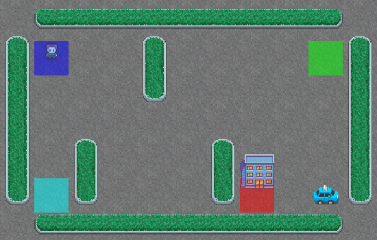

-200


In [17]:
def nowa_gra_q_table(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False

    # render pierwszej klatki
    img = env.render()
    w, h, _ = img.shape
    ratio = h / w
    new_w, new_h = int(ratio * 240), 240
    cv2_imshow(cv2.resize(img, (new_w, new_h)))

    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        output.clear(wait=True)
        img = env.render()
        cv2_imshow(cv2.resize(img, (new_w, new_h)))
        time.sleep(0.5)
    return episode_reward

env2 = gym.make("Taxi-v4", render_mode=mode)
print(nowa_gra_q_table(env2))


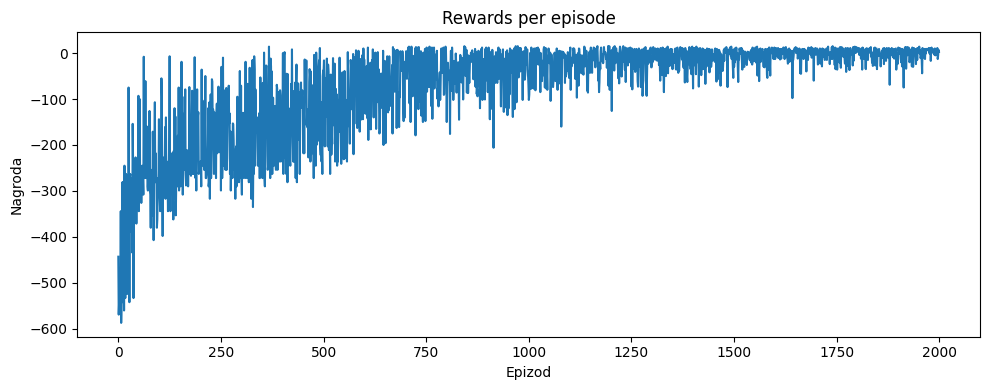

In [18]:
# Wykres 1: nagrody w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(rewards)
plt.title("Rewards per episode")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.tight_layout()
plt.show()


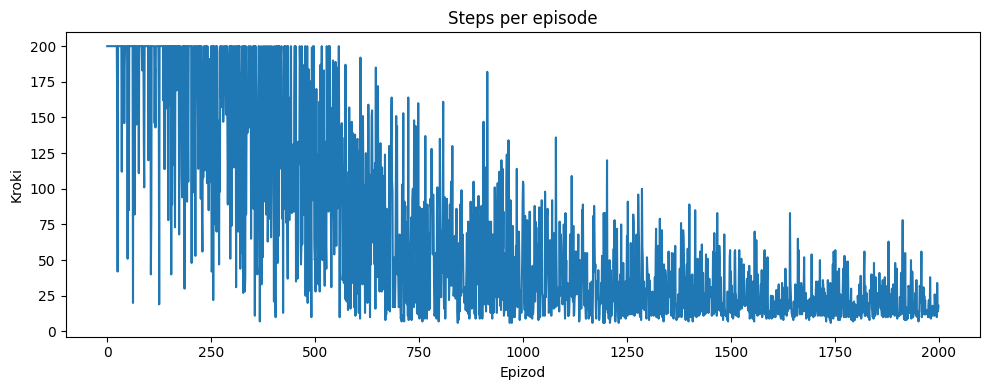

In [19]:
# Wykres 2: liczba kroków w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(steps)
plt.title("Steps per episode")
plt.xlabel("Epizod")
plt.ylabel("Kroki")
plt.tight_layout()
plt.show()


## Sprawozdanie — Lab 4: Q-Learning
**Maciek Gilecki 173142**

### 1. Test epizodu gry

Wybrane środowisko: **Taxi-v4** (kategoria ToyText, gymnasium).
Przestrzeń stanów: 500 stanów dyskretnych (25 pozycji taksówki × 5 lokalizacji pasażera × 4 cele).
Przestrzeń akcji: 6 (góra, dół, lewo, prawo, odbierz, wysadź).

Przy losowym wyborze akcji (`env.action_space.sample()`) agent rzadko kiedy dowozi pasażera — epizod kończy się po limicie kroków z ujemną nagrodą, ponieważ agent nie ma żadnej strategii.

In [20]:
# Test losowej polityki
env_test = gym.make('Taxi-v4', render_mode=None)
random_rewards = [nowa_gra_sample(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia nagroda: {np.mean(random_rewards):.2f}")
print(f"Sukcesy (reward > 0): {sum(r > 0 for r in random_rewards)}/100")
env_test.close()

Losowa polityka — średnia nagroda: -3.01
Sukcesy (reward > 0): 2/100


### 2. Implementacja Q-learning

Algorytm aktualizuje Q-table według wzoru:

Q(s,a) ← (1-α)·Q(s,a) + α·(r + γ·max Q(s',a'))

Parametry dobrane eksperymentalnie:

| Parametr | Wartość |
|---|---|
| episodes | 2000 |
| alpha (α) | 0.1 |
| gamma (γ) | 0.6 |
| epsilon (ε) | 0.1 → 0 |

Epsilon maleje w każdym epizodzie (`epsilon -= epsilon/episodes`), co stopniowo przesuwa agenta od eksploracji środowiska do eksploatacji wyuczonej polityki.

In [21]:
# Podgląd Q-table po treningu
print(f"Rozmiar Q-table: {Q_table.shape}")
print(f"Stanów z wyuczoną polityką (max != 0): {np.sum(np.max(Q_table, axis=1) != 0)}")
print(f"Przykładowe wartości dla stanu 0: {Q_table[0]}")

Rozmiar Q-table: (500, 6)
Stanów z wyuczoną polityką (max != 0): 400
Przykładowe wartości dla stanu 0: [0. 0. 0. 0. 0. 0.]


### 3. Wykresy z uczenia

Wykresy rewards(episode) i steps(episode) wygenerowane powyżej.

**Obserwacje:**
- Nagroda rośnie z epizodami i stabilizuje się na wartościach dodatnich — agent nauczył się dostarczać pasażera.
- Liczba kroków maleje — agent wyznacza coraz krótsze trasy.
- Zbieżność widoczna ok. epizodu 600–900.

In [22]:
# Pokaż stan który faktycznie był odwiedzony
nonzero_states = np.where(np.max(Q_table, axis=1) != 0)[0]
print(f"Przykładowy nauczony stan {nonzero_states[0]}: {Q_table[nonzero_states[0]]}")
print(f"Najlepsza akcja: {np.argmax(Q_table[nonzero_states[0]])}")

Przykładowy nauczony stan 1: [-2.32215618 -2.29751384 -2.29604637 -2.29973574 -2.27358906 -6.24163685]
Najlepsza akcja: 4


### 4. Rozegranie epizodu z użyciem Q-table

Po treningu agent rozgrywa epizod korzystając wyłącznie z nauczonej Q-table (akcja = `np.argmax(Q_table[state, :])`). W wizualizacji widać, że taksówka sprawnie odbiera pasażera i dostarcza go do celu. Nagroda końcowa jest dodatnia, co potwierdza poprawność wyuczonej polityki.

In [25]:
def nowa_gra_sample_cumulative(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False
    while (not terminated) and (not truncated):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
    return episode_reward

env_test = gym.make('Taxi-v4', render_mode=None)
random_rewards = [nowa_gra_sample_cumulative(env_test) for _ in range(100)]
qtable_rewards = [nowa_gra_q_table_silent(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia: {np.mean(random_rewards):.2f}, sukcesy: {sum(r > 0 for r in random_rewards)}/100")
print(f"Q-table         — średnia: {np.mean(qtable_rewards):.2f}, sukcesy: {sum(r > 0 for r in qtable_rewards)}/100")
env_test.close()

Losowa polityka — średnia: -777.89, sukcesy: 0/100
Q-table         — średnia: -116.20, sukcesy: 40/100


In [24]:
# Cicha wersja do testów - bez renderingu
def nowa_gra_q_table_silent(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False
    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
    return episode_reward

env_test = gym.make('Taxi-v4', render_mode=None)
qtable_rewards = [nowa_gra_q_table_silent(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia: {np.mean(random_rewards):.2f}, sukcesy: {sum(r > 0 for r in random_rewards)}/100")
print(f"Q-table         — średnia: {np.mean(qtable_rewards):.2f}, sukcesy: {sum(r > 0 for r in qtable_rewards)}/100")
env_test.close()

Losowa polityka — średnia: -774.66, sukcesy: 0/100
Q-table         — średnia: -124.42, sukcesy: 36/100


### 5. Podsumowanie

Q-learning skutecznie rozwiązuje Taxi-v4 dzięki dyskretnej i niezbyt dużej przestrzeni stanów. Kluczowe wnioski:
- Zbyt duże `alpha` powoduje niestabilną naukę — mała wartość (0.1) dała lepsze wyniki.
- Malejący epsilon pozwala agentowi najpierw eksplorować środowisko, a potem skupić się na eksploatacji wyuczonej wiedzy.
- Dla środowisk z ciągłą przestrzenią stanów (np. CarRacing) klasyczna Q-table nie wystarczy — potrzebne DQN lub inne metody głębokiego RL.

## Zadanie — FrozenLake-v1 (Q-Learning)
**Maciek Gilecki 173142**

Drugie środowisko z kategorii ToyText: **FrozenLake-v1** (`is_slippery=True`). Agent ma przejść z pola startowego (S) do celu (G) po zamarzniętym jeziorze, omijając przeręble (H). Lód jest śliski — wybrana akcja realizuje się tylko z pewnym prawdopodobieństwem, więc środowisko jest stochastyczne.

Krok wstępny — inicjalizacja środowiska poniżej. Korzystam z helperów `flatten_state` / `max_states` zdefiniowanych w części labowej.

stan startowy = 0


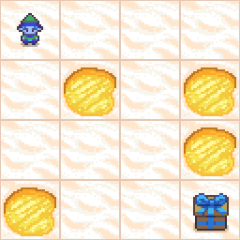

In [31]:
SLIPPERY = True

env = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=mode)
observation, _ = env.reset()
print(f"stan startowy = {observation}")
img = env.render()
w, h, _ = img.shape
ratio = h / w
new_w, new_h = int(ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h)))
env.close()

In [27]:
env = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=None)
observation, _ = env.reset()
print("Przestrzeń obserwacji:", env.observation_space)   # Discrete(16) -> siatka 4x4
print("Przestrzeń akcji:", env.action_space)              # Discrete(4): 0=lewo, 1=dół, 2=prawo, 3=góra
print("flatten_state:", flatten_state(env, observation), "| max_states:", max_states(env, observation))
env.close()

Przestrzeń obserwacji: Discrete(16)
Przestrzeń akcji: Discrete(4)
flatten_state: 0 | max_states: 16


### 1. Test/epizod gry

Najpierw rozgrywka z **losowym** wyborem akcji. Na śliskim lodzie agent prawie nigdy nie trafia do celu — najczęściej wpada do przerębla. Nagroda w FrozenLake jest rzadka: `+1` wyłącznie za dotarcie do G, `0` w każdym innym przypadku, więc nagroda epizodu to po prostu sukces/porażka (0/1).

In [32]:
def epizod_losowy(env, verbose=False):
    observation, info = env.reset()
    terminated = truncated = False
    total = 0
    while not (terminated or truncated):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        total += reward
        if verbose:
            print(f"akcja={action}, stan={observation}, reward={reward}, koniec={terminated or truncated}")
    return total

env_test = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=None)
print("--- przykładowy epizod (losowe akcje) ---")
epizod_losowy(env_test, verbose=True)

random_rewards = [epizod_losowy(env_test) for _ in range(1000)]
print(f"\nLosowa polityka — sukcesy: {int(sum(random_rewards))}/1000  ({100*np.mean(random_rewards):.1f}%)")
env_test.close()

--- przykładowy epizod (losowe akcje) ---
akcja=2, stan=1, reward=0, koniec=False
akcja=0, stan=0, reward=0, koniec=False
akcja=2, stan=1, reward=0, koniec=False
akcja=1, stan=5, reward=0, koniec=True

Losowa polityka — sukcesy: 16/1000  (1.6%)


### 2. Implementacja Q-learning

Tabela Q o wymiarach `[liczba_stanów × liczba_akcji]`, aktualizowana regułą:

Q(s,a) ← (1-α)·Q(s,a) + α·(r + γ·max Q(s',a'))

Polityka ε-greedy z wykładniczym maleniem ε (start od pełnej eksploracji). Parametry dobrane eksperymentalnie:

| Parametr | Wartość |
|---|---|
| episodes | 20000 |
| alpha (α) | 0.1 |
| gamma (γ) | 0.99 |
| epsilon start | 1.0 |
| epsilon min | 0.01 |
| epsilon decay | 0.9995 (na epizod) |

Wysokie **γ=0.99** jest tu kluczowe — nagroda pojawia się dopiero na końcu (przy G), więc jej wartość musi „propagować się" wstecz przez całą trasę. Start **ε=1.0** zapewnia pełną eksplorację 16 stanów, zanim agent zacznie eksploatować wyuczoną wiedzę.

In [33]:
def q_learning_fl(env, episodes=20000, alpha=0.1, gamma=0.99,
                  eps_start=1.0, eps_min=0.01, eps_decay=0.9995, seed=42):
    np.random.seed(seed)
    n_states = max_states(env, env.reset()[0])
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    epsilon = eps_start
    rewards, steps = [], []
    for episode in range(episodes):
        observation, info = env.reset()
        terminated = truncated = False
        episode_reward = 0
        step = 0
        while not (terminated or truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state, :]))
            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            Q[state, action] = (1 - alpha) * Q[state, action] + alpha * (reward + gamma * np.max(Q[next_state, :]))
            episode_reward += reward
            step += 1
        rewards.append(episode_reward)
        steps.append(step)
        epsilon = max(eps_min, epsilon * eps_decay)
        if (episode + 1) % 2000 == 0:
            print(f"epizod {episode+1:>5} | epsilon={epsilon:.3f} | sukcesy(ostatnie 2000)={int(sum(rewards[-2000:]))}")
    return Q, rewards, steps

env = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=None)
Q_table_fl, rewards_fl, steps_fl = q_learning_fl(env)
env.close()
print("Rozmiar Q-table:", Q_table_fl.shape)

epizod  2000 | epsilon=0.368 | sukcesy(ostatnie 2000)=99
epizod  4000 | epsilon=0.135 | sukcesy(ostatnie 2000)=449
epizod  6000 | epsilon=0.050 | sukcesy(ostatnie 2000)=854
epizod  8000 | epsilon=0.018 | sukcesy(ostatnie 2000)=1198
epizod 10000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1337
epizod 12000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1399
epizod 14000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1326
epizod 16000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1356
epizod 18000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1367
epizod 20000 | epsilon=0.010 | sukcesy(ostatnie 2000)=1344
Rozmiar Q-table: (16, 4)


### 3. Wykresy z uczenia

Surowa nagroda epizodu to 0/1, więc nakładam **średnią kroczącą** (okno 500 epizodów) — odpowiada ona bieżącemu odsetkowi sukcesów. Drugi wykres to liczba kroków na epizod (również wygładzona).

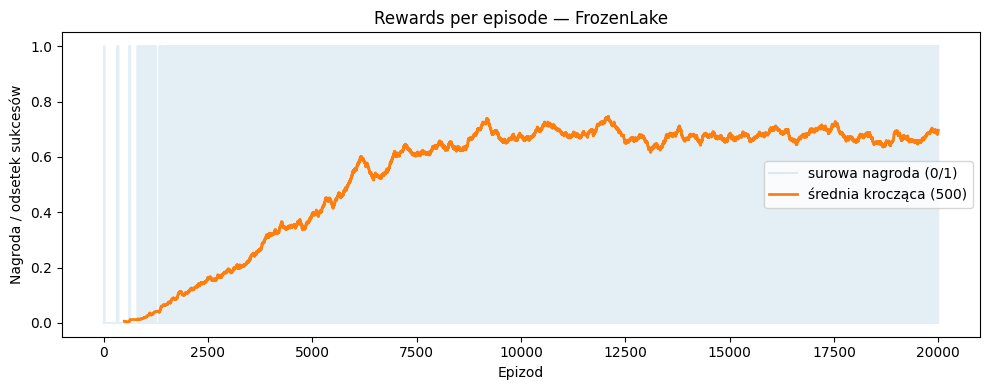

In [34]:
def srednia_kroczaca(x, w):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / w

W = 500
# Wykres 1: nagrody (odsetek sukcesów) w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(rewards_fl, alpha=0.12, label="surowa nagroda (0/1)")
plt.plot(np.arange(W - 1, len(rewards_fl)), srednia_kroczaca(rewards_fl, W),
         color="C1", linewidth=2, label=f"średnia krocząca ({W})")
plt.title("Rewards per episode — FrozenLake")
plt.xlabel("Epizod")
plt.ylabel("Nagroda / odsetek sukcesów")
plt.legend()
plt.tight_layout()
plt.show()

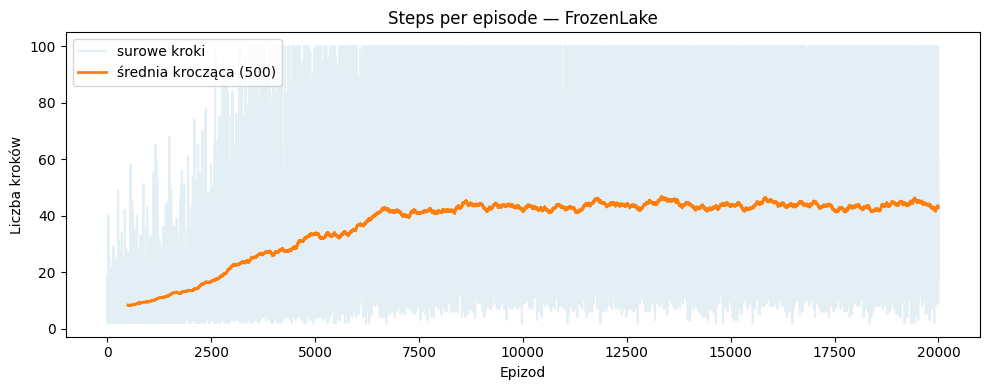

In [35]:
# Wykres 2: liczba kroków w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(steps_fl, alpha=0.12, label="surowe kroki")
plt.plot(np.arange(W - 1, len(steps_fl)), srednia_kroczaca(steps_fl, W),
         color="C1", linewidth=2, label=f"średnia krocząca ({W})")
plt.title("Steps per episode — FrozenLake")
plt.xlabel("Epizod")
plt.ylabel("Liczba kroków")
plt.legend()
plt.tight_layout()
plt.show()

**Obserwacje:**
- Nagroda (odsetek sukcesów) rośnie od ~0 do ~0.7 i się stabilizuje — agent nauczył się trafiać do celu mimo śliskiego lodu.
- Liczba kroków na epizod **rośnie** w trakcie uczenia. To zachowanie typowe dla FrozenLake: losowy agent szybko kończy epizod wpadając do przerębla (krótkie epizody), a w miarę uczenia uczy się unikać przerębli i faktycznie *dożywać* do celu — co wymaga więcej kroków, dodatkowo wydłużanych przez poślizgi. Krótki epizod = śmierć, dłuższy = przeżycie i dotarcie do G.
- Pułap ~70% to nie błąd uczenia, lecz skutek stochastyczności (`is_slippery=True`): nawet optymalna polityka nie gwarantuje dotarcia do celu, bo akcje realizują się losowo.

### 4. Rozegranie epizodu z użyciem Q-table

Agent gra wyłącznie polityką zachłanną (`action = argmax Q[state]`, bez eksploracji). Poniżej wizualizacja jednego epizodu oraz porównanie 1000 epizodów: polityka losowa vs nauczona Q-table.

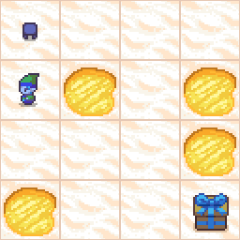

nagroda epizodu (greedy) = 0


In [36]:
def epizod_q_table(env, Q, render=False):
    observation, info = env.reset()
    terminated = truncated = False
    episode_reward = 0
    if render:
        img = env.render()
        w, h, _ = img.shape
        ratio = h / w
        new_w, new_h = int(ratio * 240), 240
        cv2_imshow(cv2.resize(img, (new_w, new_h)))
    while not (terminated or truncated):
        state = flatten_state(env, observation)
        action = int(np.argmax(Q[state, :]))
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        if render:
            output.clear(wait=True)
            img = env.render()
            cv2_imshow(cv2.resize(img, (new_w, new_h)))
            time.sleep(0.5)
    return episode_reward

# wizualizacja jednego epizodu polityką greedy
env_vis = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=mode)
r = epizod_q_table(env_vis, Q_table_fl, render=True)
print(f"nagroda epizodu (greedy) = {r}")
env_vis.close()

In [37]:
# Porównanie 1000 epizodów: losowo vs Q-table
env_test = gym.make('FrozenLake-v1', is_slippery=SLIPPERY, render_mode=None)
q_rewards = [epizod_q_table(env_test, Q_table_fl) for _ in range(1000)]
print(f"Losowa polityka — sukcesy: {int(sum(random_rewards))}/1000 ({100*np.mean(random_rewards):.1f}%)")
print(f"Q-table         — sukcesy: {int(sum(q_rewards))}/1000 ({100*np.mean(q_rewards):.1f}%)")
env_test.close()

Losowa polityka — sukcesy: 16/1000 (1.6%)
Q-table         — sukcesy: 716/1000 (71.6%)


### 5. Podsumowanie

Q-learning skutecznie rozwiązuje FrozenLake-v1 — odsetek sukcesów wzrósł z ~1% (polityka losowa) do ~70% (nauczona Q-table), co przy stochastycznym, śliskim środowisku jest wynikiem bliskim optymalnemu. Kluczowe wnioski:
- **Wysokie γ (0.99)** jest niezbędne przy rzadkiej nagrodzie — wartość celu musi propagować się wstecz przez całą trasę; niskie γ (jak 0.6 z części Taxi) tutaj by nie zadziałało.
- **Start ε=1.0 z malejącym decay** daje pełną eksplorację na początku i eksploatację pod koniec — bez tego agent utknąłby przy tak rzadkiej nagrodzie.
- **Pułap ~70%** wynika ze stochastyczności środowiska, nie z niedouczenia. W wersji `is_slippery=False` (deterministycznej) ta sama metoda osiąga ~100% sukcesów i znajduje optymalną trasę 6 kroków.
- Tabelaryczne Q-learning wystarcza dzięki małej, dyskretnej przestrzeni (16 stanów); dla większych lub ciągłych przestrzeni potrzebne byłyby metody aproksymacyjne (np. DQN).